<a href="https://colab.research.google.com/github/ene23033/repository/blob/master/pypsaFeb1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pypsa
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.5/173.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.8/92.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.0 MB/s eta 0:00:00


In [4]:
!pip install pyomo
!apt install glpk-utils
!pip install glpk

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libamd2 libcolamd2 libglpk40 libsuitesparseconfig5
Suggested packages:
  libiodbc2-dev
The following NEW packages will be installed:
  glpk-utils libamd2 libcolamd2 libglpk40 libsuitesparseconfig5
0 upgraded, 5 newly installed, 0 to remove and 20 not upgraded.
Need to get 625 kB of archives.
After this operation, 2,158 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libsuitesparseconfig5 amd64 1:5.10.1+dfsg-4build1 [10.4 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libamd2 amd64 1:5.10.1+dfsg-4build1 [21.6 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libcolamd2 amd64 1:5.10.1+dfsg-4build1 [18.0 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libglpk40 amd64 5.0-1 [361 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/universe amd64 glpk-ut

In [6]:
drive.mount('/content/drive')
path= ('/content/drive/My Drive/pypsaFeb/timeseries_2030.xlsx')

Mounted at /content/drive


In [7]:
# network.add("Load","demand",bus="electricity", p_set=demand_data["2030 Demand (MW)"].values)
ts=pd.read_excel(path, index_col=0, parse_dates=True)

In [8]:
ts.head()

,load,wind,solar
timestamp,,,
2030-01-01 00:00:00,26415.670186,3.68,0.0
2030-01-01 01:00:00,26863.402352,3.34,0.0
2030-01-01 02:00:00,26777.540854,3.15,0.0
2030-01-01 03:00:00,26823.845527,3.24,0.0
2030-01-01 04:00:00,27265.176957,3.30,0.0


In [9]:
resolution = 1
ts = ts.resample(f"{resolution}h").first()

In [10]:
n=pypsa.Network()

In [35]:
n.add('Bus','electricity')

Index(['electricity'], dtype='object')

In [36]:
n.set_snapshots(ts.index)
n.snapshots

DatetimeIndex(['2030-01-01 00:00:00', '2030-01-01 01:00:00',
               '2030-01-01 02:00:00', '2030-01-01 03:00:00',
               '2030-01-01 04:00:00', '2030-01-01 05:00:00',
               '2030-01-01 06:00:00', '2030-01-01 07:00:00',
               '2030-01-01 08:00:00', '2030-01-01 09:00:00',
               ...
               '2030-12-31 14:00:00', '2030-12-31 15:00:00',
               '2030-12-31 16:00:00', '2030-12-31 17:00:00',
               '2030-12-31 18:00:00', '2030-12-31 19:00:00',
               '2030-12-31 20:00:00', '2030-12-31 21:00:00',
               '2030-12-31 22:00:00', '2030-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq='h')

In [37]:
n.snapshot_weightings.loc[:, :] = resolution

In [38]:
carriers = [
    "solar",
    "onwind",
    "coal",
    "gas",
    "hydro",
    "nuclear",
    "BESS",
    "PHES",
    "Biomass",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "aquamarine", "black", "brown", "magenta", "yellowgreen","red","gold","green"],
)

Index(['solar', 'onwind', 'coal', 'gas', 'hydro', 'nuclear', 'BESS', 'PHES',
       'Biomass'],
      dtype='object')

In [39]:
n.add(
    "Load",
    "demand",
    bus="electricity",
    p_set=ts.load,
)

Index(['demand'], dtype='object')

<Axes: xlabel='Months', ylabel='Demand (MW)'>

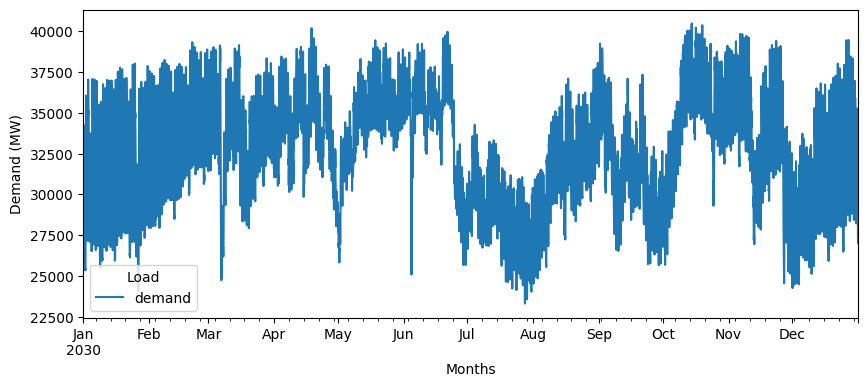

In [40]:
n.loads_t.p_set.plot(figsize=(10, 4), ylabel="Demand (MW)", xlabel="Months")

In [41]:
n.add(
    "Generator",
    "coal",
    bus="electricity",
    carrier="coal",
    capital_cost=1120000,
    marginal_cost=28000,
    efficiency=35,
    p_nom_extendable=False,
)

Index(['coal'], dtype='object')

In [45]:
for tech in ["solar"]:
    n.add(
        "Generator",
        tech,
        bus="electricity",
        carrier=tech,
        p_max_pu=ts[tech],
        capital_cost=550000,
        marginal_cost=4840,
        efficiency=20,
        p_nom_extendable=True,
    )

In [46]:
for tech in ["wind"]:
    n.add(
        "Generator",
        tech,
        bus="electricity",
        carrier=tech,
        p_max_pu=ts[tech],
        capital_cost=900000,
        marginal_cost=18000,
        efficiency=43,
        p_nom_extendable=True,
    )

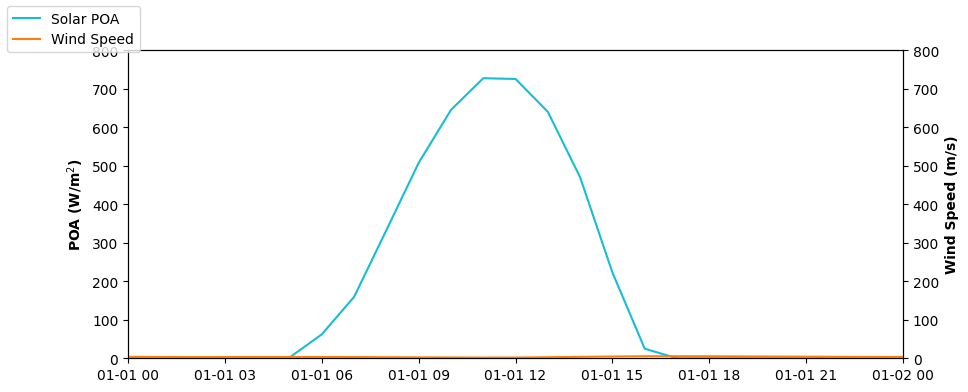

In [82]:
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.set_xlim(pd.Timestamp('2030-01-01'), pd.Timestamp('2030-01-02'))
# Plot solar POA on the left y-axis
color='tab:cyan'
ax1.plot(ts.index, ts["solar"], label="Solar POA",color=color)
ax1.set_ylabel("POA (W/m${^2}$)",weight='bold')
ax1.tick_params(axis="y")

# Create a second y-axis (right side)
color='tab:orange'
ax2 = ax1.twinx()
ax2.plot(ts.index, ts["wind"], label="Wind Speed",color=color)
ax2.set_ylabel("Wind Speed (m/s)", weight='bold')
ax2.tick_params(axis="y")

ax1.set_ylim(0, 800)
ax2.set_ylim(0, 800)
fig.legend(loc='upper left')

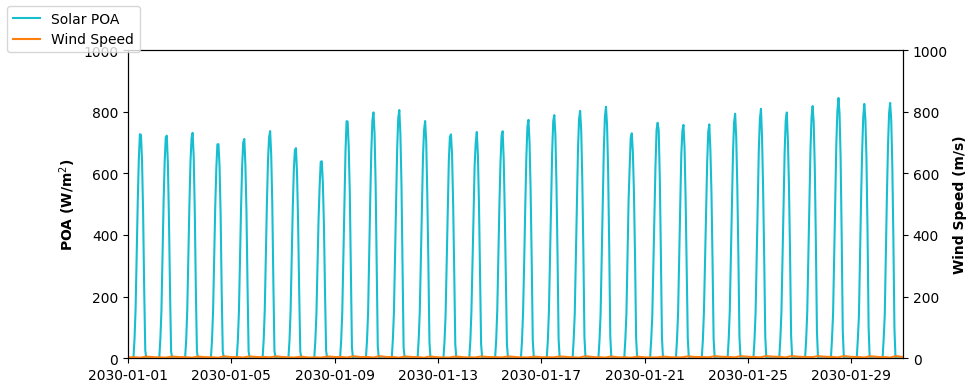

In [84]:
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.set_xlim(pd.Timestamp('2030-01-01'), pd.Timestamp('2030-01-31'))
# Plot solar POA on the left y-axis
color='tab:cyan'
ax1.plot(ts.index, ts["solar"], label="Solar POA",color=color)
ax1.set_ylabel("POA (W/m${^2}$)",weight='bold')
ax1.tick_params(axis="y")

# Create a second y-axis (right side)
color='tab:orange'
ax2 = ax1.twinx()
ax2.plot(ts.index, ts["wind"], label="Wind Speed",color=color)
ax2.set_ylabel("Wind Speed (m/s)", weight='bold')
ax2.tick_params(axis="y")

ax1.set_ylim(0, 1000)
ax2.set_ylim(0, 1000)
fig.legend(loc='upper left')

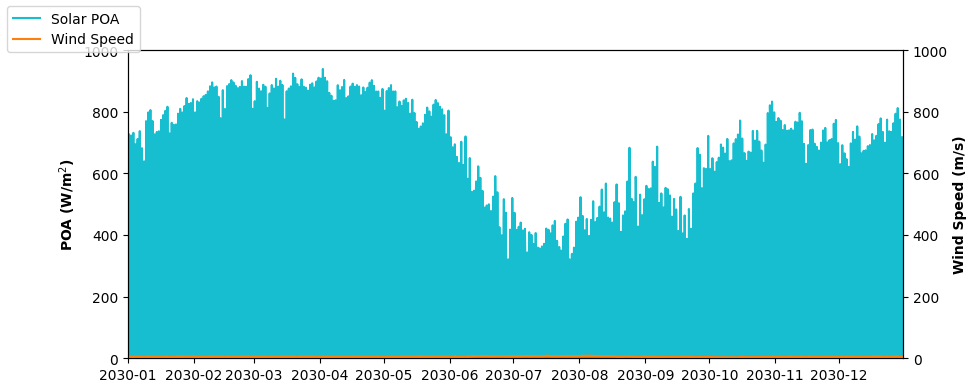

In [86]:
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.set_xlim(pd.Timestamp('2030-01-01'), pd.Timestamp('2030-12-31'))
# Plot solar POA on the left y-axis
color='tab:cyan'
ax1.plot(ts.index, ts["solar"], label="Solar POA",color=color)
ax1.set_ylabel("POA (W/m${^2}$)",weight='bold')
ax1.tick_params(axis="y")

# Create a second y-axis (right side)
color='tab:orange'
ax2 = ax1.twinx()
ax2.plot(ts.index, ts["wind"], label="Wind Speed",color=color)
ax2.set_ylabel("Wind Speed (m/s)", weight='bold')
ax2.tick_params(axis="y")

ax1.set_ylim(0, 1000)
ax2.set_ylim(0, 1000)
fig.legend(loc='upper left')

<Axes: xlabel='snapshot', ylabel='timeseries'>

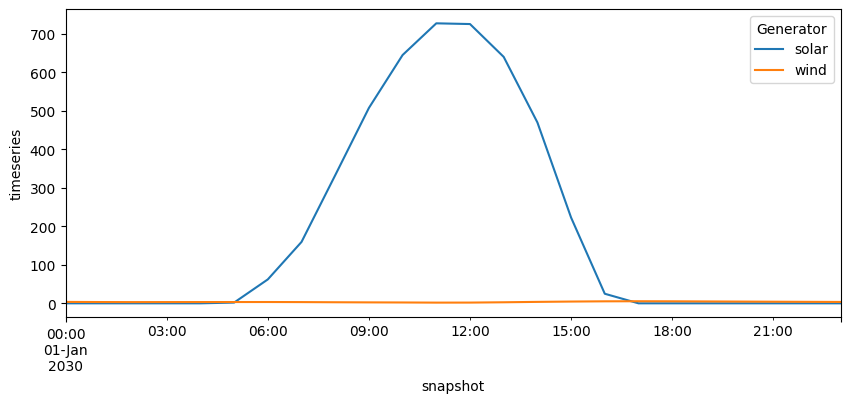

In [50]:
n.generators_t.p_max_pu.loc["2030-01-01"].plot(figsize=(10, 4), ylabel="timeseries")

In [92]:
!pip install highspy

In [93]:
n.optimize(solver_name="highs")

Index(['Electricity', 'electricity'], dtype='object', name='Bus')
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 36.79it/s]


('ok', 'optimal')

In [97]:
n.objective / 1e9 #(Total system cost in USD billions per year)

2338.947097737092

In [96]:
n.generators.p_nom_opt.div(1e3)  # (Total optimised capacity in GW)

,p_nom_opt
Generator,
solar,30.293253
coal,0.000000
wind,23.633911


In [98]:
n.snapshot_weightings.generators @ n.generators_t.p.div(1e6)  # (Total energy generation in TWh units)

,generators
Generator,
solar,158.681544
coal,0.000000
wind,127.834183


In [99]:
(n.statistics.capex() + n.statistics.opex()).div(1e6)

component  carrier
Generator  solar               NaN
           wind       2.322286e+06
dtype: float64

In [106]:
def plot_dispatch(n, time="2030-01"):
    p_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().div(1e3)

    if not n.storage_units.empty:
        sto = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T.div(1e3)
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)

    fig, ax = plt.subplots(figsize=(6, 3))

    color = p_by_carrier.columns.map(n.carriers.color)

    p_by_carrier.where(p_by_carrier > 0).loc[time].plot.area(
        ax=ax,
        linewidth=0,
        color=color,
    )

    charge = p_by_carrier.where(p_by_carrier < 0).dropna(how="all", axis=1).loc[time]

    if not charge.empty:
        charge.plot.area(
            ax=ax,
            linewidth=0,
            color=charge.columns.map(n.carriers.color),
        )

    n.loads_t.p_set.sum(axis=1).loc[time].div(1e3).plot(ax=ax, c="k")

    plt.legend(loc=(1.05, 0))
    ax.set_ylabel("GW")
    ax.set_ylim(0, 200)

<ipython-input-106-a9b283c868c9>:2: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



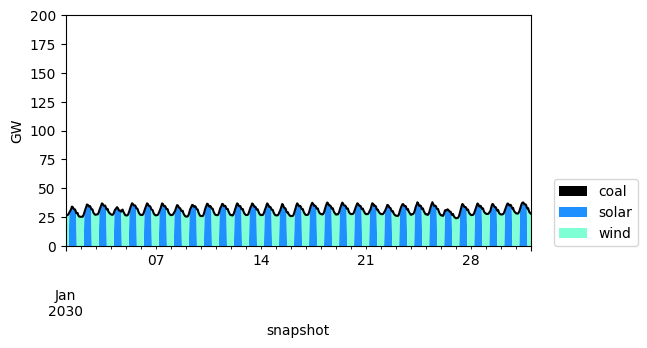

In [107]:
plot_dispatch(n)

In [108]:
n.add(
    "StorageUnit",
    "BESS",
    bus="electricity",
    carrier="battery storage",
    max_hours=4,
    capital_cost=850000,
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

Index(['BESS'], dtype='object')

In [109]:
n.optimize(solver_name="highs")

Index(['BESS'], dtype='object', name='StorageUnit')
Index(['Electricity', 'electricity'], dtype='object', name='Bus')
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 48.42it/s]


('ok', 'optimal')

In [113]:
n.generators.p_nom_opt.div(1e3)  # (Total optimised capacity in GW)

,p_nom_opt
Generator,
solar,2.276972
coal,0.000000
wind,0.250188


In [111]:
n.snapshot_weightings.generators @ n.generators_t.p.div(1e6)  # (Total energy generation in TWh units)

,generators
Generator,
solar,286.485254
coal,0.000000
wind,0.030472


In [112]:
n.storage_units.p_nom_opt  # MW

,p_nom_opt
StorageUnit,
BESS,106479.895734


In [6]:
# Add the missing buses
buses = ["Solar", "Wind", "Coal","Gas","Hydro","Nuclear","BESS", "PHES", "Maharashtra","Biomass"]
for bus in buses:
    if bus not in network.buses.index:
        network.add("Bus", bus)

In [18]:
# Installed capacities in MW (as per 2023 data)
installed_capacity_2023 = {
    "Solar": 10097.67,
    "Wind": 5207.98,
    "Coal": 25404.24,
    "Nuclear": 879.33,
    "Biomass": 2568,
    "Gas": 3512.73,
    "Hydro": 3331.84,
    "PHES": 400
}

installed_capacity_2030 = {
    "solar": 0,
    "Wind": 0,
    "Coal": 25404.24,
    "Nuclear": 879.33,
    "Biomass": 0,
    "Gas": 3512.73,
    "Hydro": 0,
    "PHES": 0,
    "BESS": 0
}

In [19]:
# Load solar and wind data
solar_data = pd.read_csv(path2)["POA"].values
wind_data = pd.read_csv(path2)["wind_speed_100m"].values

In [ ]:
solar_pu = solar_data.flatten()  # Convert to NumPy array
wind_pu = wind_data.flatten()    # Convert to NumPy array

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
solar_pu = np.array(solar_pu).flatten()
wind_pu = np.array(wind_pu).flatten()

generators_2023 = pd.DataFrame({
    "type": ["Solar", "Wind", "Coal", "Gas", "Hydro", "Nuclear", "Biomass"],
    "bus": ["electricity"] * 7,
    "p_nom": [10097.67, 5207.98, 25404.24, 3512.73, 3331.84, 879.33, 2568],  # Installed capacity
    "p_nom_extendable": [False]*7,
    "efficiency": [0.20, 0.43, 0.35, 0.44, 0.92, 0.33, 0.24],
    "lifetime": [25, 25, 30, 30, 50, 50, 25],
    "plf": [0.2, 0.3, 0.85, 0.60, 0.30, 0.85, 0.80],
    "emission_factor": [0, 0, 0.98, 0.61, 0, 0, 0.045],  # kg CO2e/kWh
    "capital_cost": [550000, 900000, 1120000, 640000, 1100000, 1790000, 700000],  # $/kW
    "annual_fixed_om": [0.88, 2, 2.5, 3.6, 2, 3.7, 2],  # % of total cost
    "variable_cost": [0, 0, 0, 0, 0, 0, 0.001],  # $/MWh
    "msg_level": [0, 0, 75, 40, 0, 80, 40],  # % capacity
    "ramp_rate": [0, 0, 0.5, 3, 5, 0.3, 1],  # % capacity per minute
    "min_on_off_time": [0, 0, 1.5, 1.33, 1.5, 0, 2],
    "hot_startup": [0, 0, 2, 1.5, 0, 2, 2],
    "warm_startup": [0, 0, 5, 2, 0, 5, 4],
    "cold_startup": [0, 0, 10, 3, 0, 10, 8],
    "hot_startup_cost": np.array([0, 0, 190, 36, 0, 0, 0]) * (10**6),  # $/MW
    "warm_startup_cost": np.array([0, 0, 300, 55, 0, 0, 0]) * (10**6),  # $/MW
    "cold_startup_cost": np.array([0, 0, 385, 78, 0, 0, 0]) * (10**6)  # $/MW
})

p_max_pu = {
    "Solar": pd.Series(solar_pu),
    "Wind": pd.Series(wind_pu),
    "Coal": 1.0,
    "Gas": 1.0,
    "Hydro": 1.0,
    "Nuclear": 1.0,
    "Biomass": 1.0
}

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
# generators_2023["p_max_pu"] = generators_2023["type"].map(p_max_pu)

generators_2030 = generators_2023.copy()  # Copy existing data
generators_2030["p_nom"] = [None, None, 25404.24, 3512.73, None, 879.33, None]  # Expandable renewables
generators_2030["p_nom_extendable"] = [True, True, False, False, True, False, True]

# Map p_max_pu again
generators_2030["p_max_pu"] = generators_2030["type"].map(p_max_pu)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
# Reindex solar_pu and wind_pu to match network snapshots
solar_pu = pd.Series(solar_pu, index=network.snapshots)
wind_pu = pd.Series(wind_pu, index=network.snapshots)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
# generators_2030 = generators_2023.copy()
# generators_2030["p_nom"] = [None, None, 25404.24, 3512.73, None, 879.33, None]
# generators_2030["p_nom_extendable"] = [True, True, False, False, True, False, True]
# generators_2030["capital_cost"]= [420000, 860000, 1120000, 640000, 1100000, 1600000, 700000]

# # Add generators for 2023
# for _, row in generators_2023.iterrows():
#     network.add("Generator", row["type"] + "_2023",
#                 bus=row["bus"],
#                 p_nom=row["p_nom"],
#                 p_nom_extendable=row["p_nom_extendable"],
#                 capital_cost=row["capital_cost"],
#                 marginal_cost=row["variable_cost"],
#                 efficiency=row["efficiency"],
#                 p_max_pu=row["p_max_pu"])

# # Add generators for 2030
# for _, row in generators_2030.iterrows():
#     network.add("Generator", row["type"] + "_2030",
#                 bus=row["bus"],
#                 p_nom=row["p_nom"] if row["p_nom"] is not None else 0,
#                 p_nom_extendable=row["p_nom_extendable"],
#                 capital_cost=row["capital_cost"],
#                 marginal_cost=row["variable_cost"],
#                 efficiency=row["efficiency"],
#                 p_max_pu=row["p_max_pu"])

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
network.add("StorageUnit", "PHES_2023",
            bus="PHES",
            max_hours=6)

network.add("StorageUnit", "BESS_2023",
            bus="BESS",
            max_hours=4)


# Storage parameters for 2023 and 2030
storage_2023 = pd.DataFrame({
    "type": ["PHES","BESS"],
    "bus": ["electricity"]*2,
    "p_nom": [400,0],  # Installed PHES capacity in MW for 2023
    "p_nom_extendable": [False, False],
    "capital_cost": [810000, 850000],  # $/MW
    "efficiency_store": [0.75, 0.90],
    "efficiency_dispatch": [0.75, 0.90],
})

storage_2030 = pd.DataFrame({
    "type": ["PHES", "BESS"],
    "bus": ["electricity", "electricity"],
    "p_nom": [None, None],
    "p_nom_extendable": [True, True],
    "capital_cost": [810000, 530000],  # $/MW
    "efficiency_store": [0.75, 0.90],
    "efficiency_dispatch": [0.75, 0.90],
})

# # Add storage for 2023
# for _, row in storage_2023.iterrows():
#     network.add("StorageUnit", row["type"] + "_2023",
#                 bus=row["bus"],
#                 p_nom=row["p_nom"],
#                 p_nom_extendable=row["p_nom_extendable"],
#                 capital_cost=row["capital_cost"] ,
#                 efficiency_store=row["efficiency_store"],
#                 efficiency_dispatch=row["efficiency_dispatch"])

# # Add storage for 2030
# for _, row in storage_2030.iterrows():
#     network.add("StorageUnit", row["type"] + "_2030",
#                 bus=row["bus"],
#                 p_nom=row["p_nom"] if row["p_nom"] is not None else 0,
#                 p_nom_extendable=row["p_nom_extendable"],
#                 capital_cost=row["capital_cost"] ,
#                 efficiency_store=row["efficiency_store"],
#                 efficiency_dispatch=row["efficiency_dispatch"])


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [ ]:
network.optimize()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.

Index(['Solar', 'Wind', 'Coal', 'Gas', 'Hydro', 'Nuclear', 'BESS', 'PHES',
       'Maharashtra', 'Biomass'],
      dtype='object', name='Bus')


ValueError: Empty LHS with non-zero RHS in nodal balance constraint.

In [ ]:
print(network.buses)